In [21]:
import os
os.chdir("c:\\Users\\marti\\OneDrive\\Documents\\CS Year 2\\Group Project\\bs-meter")
import pandas
import numpy as np
from matplotlib import pyplot as plt
from website import xgb
from website.roberta import roberta_classify
import re


In [ ]:
#transformation we are using to spread out xgb outputs
def log_transform(x):
    a = 45.56
    b = 0.1

    y = a* np.log(b * x + 1)

    return y


#cleaning text, only for xgboost
def parse_text(text):
    cleaned_text = re.sub(r'[^a-zA-Z0-9.]+', ' ', text)
    return cleaned_text

#calculate bs score
def get_bs_score(text):
    p_text = parse_text(text)

    type, val = roberta_classify(text, "./model_training/Roberta_Model_testing_4")
    if type == 0:
        val = 1 - val
    value1 = min(100, log_transform(xgb.score(p_text)[0][1] * 100))
    value2 = val * 100
    value = (value1 + value2) // 2
    return (value1,value2,value)

In [ ]:
climate_articles_filepath = "dataset/climate_policy_articles/"
oil_and_gas_filepath = 'dataset/oil_and_gas/'

charnum = 5000
articles = []
oil_and_gas = []
#reading random samples of text from the climate articles
for filename in os.listdir(climate_articles_filepath):
    f = open(climate_articles_filepath + filename,"r", errors='ignore')
    text = f.read()
    start_point = np.random.randint(10000)
    truncated_text = text[start_point:start_point+charnum]
    articles.append(truncated_text)

#reading random samples of text from oil and gas companies
for filename in os.listdir(oil_and_gas_filepath):
    f = open(oil_and_gas_filepath + filename, errors="ignore")
    file = f.read()
    cleaned_text = re.sub('[^A-Za-z0-9 ]+', '', file)
    start_point_1 = np.random.randint(0,10000)
    start_point_2 = np.random.randint(0,10000)
    start_point_3 = np.random.randint(0,10000)
    truncated_text_1 = file[start_point_1:start_point_1 + int(charnum)]
    truncated_text_2 = file[start_point_2:start_point_2 + int(charnum)]
    truncated_text_3 = file[start_point_3:start_point_3 + int(charnum)]
    oil_and_gas.extend([truncated_text_1, truncated_text_2, truncated_text_3])


#creating dataframes for each set of texts, and calculating bs scores 
articles_df = pandas.DataFrame({'text' : articles})
oil_and_gas_df = pandas.DataFrame({'text' : oil_and_gas})

result = articles_df['text'].apply(get_bs_score)
result_df = pandas.DataFrame.from_records(result,columns= ["xgb","roBERTa","bs-score"])
articles_df['xgb'] = result_df['xgb']
articles_df['roBERTa'] = result_df["roBERTa"]
articles_df['bs_score'] = result_df['bs-score']


result = oil_and_gas_df['text'].apply(get_bs_score)
result_df = pandas.DataFrame.from_records(result,columns= ["xgb","roBERTa","bs-score"])
oil_and_gas_df['xgb'] = result_df['xgb']
oil_and_gas_df['roBERTa'] = result_df["roBERTa"]
oil_and_gas_df['bs_score'] = result_df['bs-score']


0     66.0
1      4.0
2     54.0
3     13.0
4     13.0
5     13.0
6     80.0
7     67.0
8     20.0
9     20.0
10    17.0
11    37.0
12    17.0
13    23.0
14    18.0
15    15.0
16    23.0
17    26.0
18    62.0
19    35.0
20    35.0
21    34.0
22    36.0
23    10.0
24    70.0
25    70.0
26     8.0
27    12.0
28    67.0
29    18.0
Name: bs_score, dtype: float64
0     24.0
1      5.0
2     10.0
3     10.0
4     25.0
5      9.0
6      9.0
7      9.0
8      1.0
9      7.0
10     1.0
11    14.0
12     5.0
13    50.0
14     5.0
15     3.0
16    12.0
17    50.0
18    50.0
19    50.0
20    20.0
21     7.0
22    11.0
23    23.0
24    20.0
25    62.0
26    13.0
27    50.0
28    15.0
29    11.0
Name: bs_score, dtype: float64


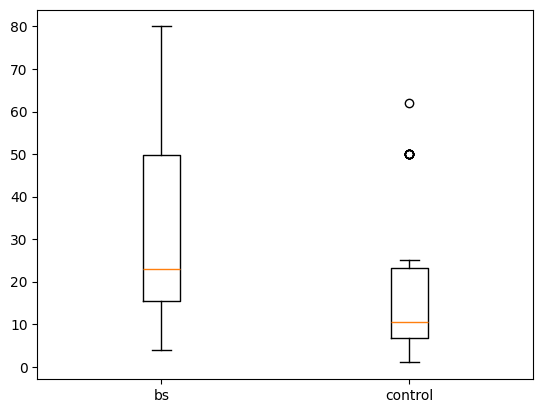

In [ ]:
#plotting distributions of bs_scores to compare
plt.boxplot([oil_and_gas_df["bs_score"], articles_df["bs_score"]], labels=['bs', 'control'])
plt.savefig("model_testing/test_results_with_scaling/climate_test")
